# Autoencoders

In [ ]:
import sys
sys.path.insert(0, '/app/data/deeplearning/course22p2_zh')

In [ ]:
import pickle,gzip,math,os,time,shutil,torch,matplotlib as mpl,numpy as np,matplotlib.pyplot as plt
import fastcore.all as fc
from collections.abc import Mapping
from pathlib import Path
from operator import attrgetter,itemgetter
from functools import partial

from torch import tensor,nn,optim
from torch.utils.data import DataLoader,default_collate
import torch.nn.functional as F
import torchvision.transforms.functional as TF
from datasets import load_dataset,load_dataset_builder

from fastprogress import progress_bar,master_bar
from miniai.datasets import *
from miniai.training import *
from miniai.conv import *

In [ ]:
from fastcore.test import test_close

torch.set_printoptions(precision=2, linewidth=140, sci_mode=False)
torch.manual_seed(1)
mpl.rcParams['image.cmap'] = 'gray'

import logging
logging.disable(logging.WARNING)

## Data

In [ ]:
x,y = 'image','label'
name = "fashion_mnist"
dsd = load_dataset(name)

fashion_mnist/train-00000-of-00001.parqu(…):   0%|          | 0.00/30.9M [00:00<?, ?B/s]

fashion_mnist/test-00000-of-00001.parque(…):   0%|          | 0.00/5.18M [00:00<?, ?B/s]

Generating train split:   0%|          | 0/60000 [00:00<?, ? examples/s]

Generating test split:   0%|          | 0/10000 [00:00<?, ? examples/s]

In [ ]:
@inplace
def transformi(b): b[x] = [TF.to_tensor(o) for o in b[x]]

In [ ]:
bs = 256
tds = dsd.with_transform(transformi)

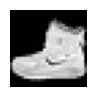

In [ ]:
ds = tds['train']
img = ds[0]['image']
show_image(img, figsize=(1,1));

In [ ]:
img.shape

torch.Size([1, 28, 28])

In [ ]:
img[:, 10:12, 10:12]

tensor([[[0.00, 0.00],
         [0.01, 0.00]]])

img被缩放到0-1之间，为什么show_image还是能正常显示

##### 🤖Reply🤖<!-- SOLVEIT_SEPARATOR_7f3a9b2c -->

好问题！关键在 `TF.to_tensor` 和 `show_image`（其实背后是 matplotlib 的 `imshow`）之间有一个「约定」：

- `TF.to_tensor` 把像素从 [0, 255] 缩放到 [0.0, 1.0]（浮点数）
- matplotlib 的 `imshow` 在处理 **浮点数** 图片时，默认认为 **0.0 = 黑色，1.0 = 白色**

所以数据范围变了，但映射关系也随之调整了，显示效果自然是对的。可以用一个小实验验证：

```python
# 试试看把 img 的值乘 255，再传给 show_image
show_image(img * 255, figsize=(1,1))
```

你猜会看到什么？试试看。

<details class='token-usage-details'><summary>$0.0003</summary>

`total=8,946 | in=8,535 | out=411 | cached=93.0% | reasoning=240 | searches=0 | $0.0003`

</details>


In [ ]:
cf = collate_dict(ds)

In [ ]:
dsd.items()

dict_items([('train', Dataset({
    features: ['image', 'label'],
    num_rows: 60000
})), ('test', Dataset({
    features: ['image', 'label'],
    num_rows: 10000
}))])

In [ ]:
def collate_(b): return to_device(cf(b))
def data_loaders(dsd, bs, **kwargs): return {k:DataLoader(v, bs, **kwargs) for k,v in dsd.items()}

In [ ]:
dls = data_loaders(tds, bs, collate_fn=collate_)

In [ ]:
dls

{'train': <torch.utils.data.dataloader.DataLoader at 0x724ba4412360>,
 'test': <torch.utils.data.dataloader.DataLoader at 0x724ba4542450>}

In [ ]:
dt = dls['train']
dv = dls['test']

xb,yb = next(iter(dt))

In [ ]:
y

'label'

In [ ]:
labels = ds.features[y].names

In [ ]:
labels

['T - shirt / top',
 'Trouser',
 'Pullover',
 'Dress',
 'Coat',
 'Sandal',
 'Shirt',
 'Sneaker',
 'Bag',
 'Ankle boot']

In [ ]:
yb[:16]

tensor([9, 0, 0, 3, 0, 2, 7, 2, 5, 5, 0, 9, 5, 5, 7, 9])

In [ ]:
lbl_getter = itemgetter(*yb[:16])
titles = lbl_getter(labels)

itemgetter(*yb[:16])表示什么意思

##### 🤖Reply🤖<!-- SOLVEIT_SEPARATOR_7f3a9b2c -->

这个写法分两步拆解：

**1. `yb[:16]`** — 取前 16 个 label 值，得到：
```
tensor([9, 0, 0, 3, 0, 2, 7, 2, 5, 5, 0, 9, 5, 5, 7, 9])
```

**2. `*yb[:16]`** — 星号 `*` 把那个 tensor "拆开"（unpack）成 16 个单独的参数。

所以 `itemgetter(*yb[:16])` 等价于：
```python
itemgetter(9, 0, 0, 3, 0, 2, 7, 2, 5, 5, 0, 9, 5, 5, 7, 9)
```

**`itemgetter`** 是 Python 内置的 `operator` 模块里的函数，它返回一个**可调用对象**。当你把这个对象用在某个序列（比如 `labels` 列表）上时，它会返回对应索引位置的元素组成的**元组**。

所以最后 `lbl_getter(labels)` 就相当于：
```python
(labels[9], labels[0], labels[0], labels[3], ...)
```
得到：
```
('Ankle boot', 'T - shirt / top', 'T - shirt / top', 'Dress', ...)
```

一句话总结：**用 batch 里实际出现的标签编号，去 `labels` 列表里查出对应的名字**，方便后面显示图片时写标题。

你想继续了解 `itemgetter` 的细节，还是往下做下一步？

<details class='token-usage-details'><summary>$0.0006</summary>

`total=10,244 | in=9,586 | out=658 | cached=82.8% | reasoning=291 | searches=0 | $0.0006`

</details>


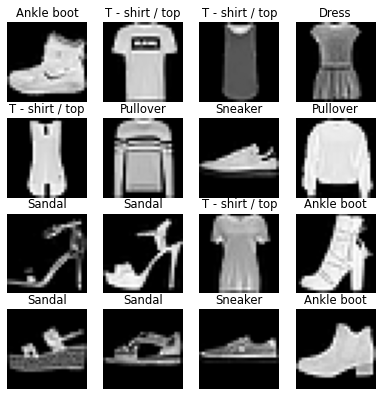

In [ ]:
mpl.rcParams['figure.dpi'] = 70
show_images(xb[:16], imsize=1.7, titles=titles)

## Warmup - classify

In [ ]:
from torch import optim

bs = 256
lr = 0.4

In [ ]:
cnn = nn.Sequential(
    conv(1 ,4),            #14x14
    conv(4 ,8),            #7x7
    conv(8 ,16),           #4x4
    conv(16,16),           #2x2
    conv(16,10, act=False),
    nn.Flatten()).to(def_device)

为什么最后需要一步Flatten

##### 🤖Reply🤖<!-- SOLVEIT_SEPARATOR_7f3a9b2c -->

好问题。关键看最后 `conv(16, 10, act=False)` 的输出是什么形状。

每个 `conv` 默认 stride=2，空间尺寸逐层减半：

```
输入:  [batch, 1,  28, 28]
conv1: [batch, 4,  14, 14]
conv2: [batch, 8,  7,   7]
conv3: [batch, 16, 4,   4]
conv4: [batch, 16, 2,   2]
conv5: [batch, 10, 1,   1]   ← 最后一个 conv
```

所以最后的输出是 `[batch, 10, 1, 1]` — 每个样本是一个 **4 维 tensor**（batch, channel, height, width）。

但交叉熵损失函数（`F.cross_entropy`）期望的是 `[batch, 10]` 这样的 **2 维**输入。`Flatten` 就把后面的 1×1 拍平，变成 `[batch, 10]`。

<details class='token-usage-details'><summary>$0.0005</summary>

`total=11,045 | in=10,361 | out=684 | cached=90.2% | reasoning=449 | searches=0 | $0.0005`

</details>


Flatten不是把所有维度展平变成一维吗

##### 🤖Reply🤖<!-- SOLVEIT_SEPARATOR_7f3a9b2c -->

你说得对——在一般的理解中"Flatten"就是把所有东西压成一维。但 **`nn.Flatten()` 是带特例的**：

PyTorch 的 `nn.Flatten()` **默认保留第 0 维（batch 维）不动**，只展平后面的所有维度。

所以：
```python
# 输入形状 [256, 10, 1, 1]
nn.Flatten()(x).shape
# 输出 [256, 10]     ← 不是 [2560]
```

只有你明确写 `nn.Flatten(start_dim=0)` 才会把 batch 维也拍掉。

这样设计是因为**绝大多数时候**你都只想拍平特征维，而 batch 维要保留。可以试试：

```python
x = torch.randn(256, 10, 1, 1)
print(x.shape)
print(nn.Flatten()(x).shape)
print(nn.Flatten(start_dim=0)(x).shape)
```

看看结果分别是什么？

<details class='token-usage-details'><summary>$0.0003</summary>

`total=11,026 | in=10,662 | out=364 | cached=92.4% | reasoning=141 | searches=0 | $0.0003`

</details>


In [ ]:
opt = optim.SGD(cnn.parameters(), lr=lr)
loss,acc = fit(5, cnn, F.cross_entropy, opt, dt, dv)

0 0.8898194598197937 0.6791


1 0.5643237183570862 0.7957


2 0.4668865334033966 0.8341


3 0.43780086879730223 0.8443


4 0.42495229828357695 0.8486


In [ ]:
dsd['train'][0]

{'image': <PIL.PngImagePlugin.PngImageFile image mode=L size=28x28>,
 'label': 9}

## Autoencoder

In [ ]:
def deconv(ni, nf, ks=3, act=True):
    layers = [nn.UpsamplingNearest2d(scale_factor=2),
              nn.Conv2d(ni, nf, stride=1, kernel_size=ks, padding=ks//2)]
    if act: layers.append(nn.ReLU())
    return nn.Sequential(*layers)

In [ ]:
def eval(model, loss_func, valid_dl, epoch=0):
    model.eval()
    with torch.no_grad():
        tot_loss,count = 0.,0
        for xb,_ in valid_dl:
            pred = model(xb)
            n = len(xb)
            count += n
            tot_loss += loss_func(pred,xb).item()*n
    print(epoch, f'{tot_loss/count:.3f}')

In [ ]:
def fit(epochs, model, loss_func, opt, train_dl, valid_dl):
    for epoch in range(epochs):
        model.train()
        for xb,_ in train_dl:
            loss = loss_func(model(xb), xb)
            loss.backward()
            opt.step()
            opt.zero_grad()
        eval(model, loss_func, valid_dl, epoch)

In [ ]:
ae = nn.Sequential(   #28x28
    nn.ZeroPad2d(2),  #32x32
    conv(1,2),        #16x16
    conv(2,4),        #8x8
#     conv(4,8),        #4x4
#     deconv(8,4),      #8x8
    deconv(4,2),      #16x16
    deconv(2,1, act=False), #32x32
    nn.ZeroPad2d(-2), #28x28
    nn.Sigmoid()
).to(def_device)

为什么最后还要接一个sigmoid

##### 🤖Reply🤖<!-- SOLVEIT_SEPARATOR_7f3a9b2c -->

好问题！关键看**输入图片的像素范围**。

你用 `TF.to_tensor` 已经把图片像素缩放到了 **[0, 1]** 之间。那么自编码器的输出也应该落在 [0, 1] 范围，才能和输入做比较（用 MSE 损失）。

但最后一个 `deconv(2, 1, act=False)` 的激活函数是线性的，它的输出可以是**任何值**（负数、大于 1 的数等等）。**Sigmoid** 把输出压缩到 **(0, 1)**，使输出的范围与目标一致。

反过来想：如果去掉 sigmoid，网络的输出取值范围是 `(-∞, +∞)`，而目标在 `[0, 1]` 之间，模型还得额外学一个"裁剪"的机制，训练会更困难。加上 sigmoid 后，模型只需专注于让输出逼近目标值就行。

<details class='token-usage-details'><summary>$0.0004</summary>

`total=12,336 | in=11,809 | out=527 | cached=94.3% | reasoning=336 | searches=0 | $0.0004`

</details>


In [ ]:
eval(ae, F.mse_loss, dv)

0 0.182


In [ ]:
opt = optim.AdamW(ae.parameters(), lr=0.01)
fit(5, ae, F.mse_loss, opt, dt, dv)

0 0.016


1 0.014


2 0.013


3 0.013


4 0.013


In [ ]:
opt = optim.AdamW(ae.parameters(), lr=0.1)
fit(5, ae, F.mse_loss, opt, dt, dv)

0 0.027


1 0.027


2 0.026


3 0.026


4 0.026


In [ ]:
xb.shape

torch.Size([256, 1, 28, 28])

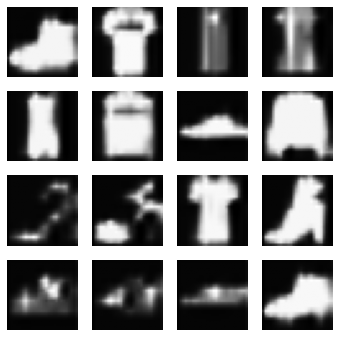

In [ ]:
p = ae(xb)
show_images(p[:16].data.cpu(), imsize=1.5)

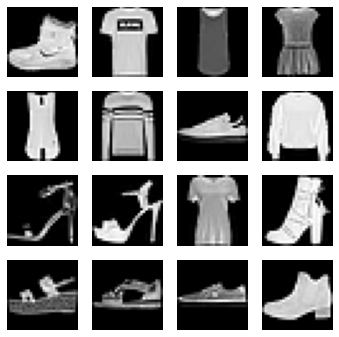

In [ ]:
show_images(xb[:16].data.cpu(), imsize=1.5)